# Biodiversity in U.S. National Parks Portfolio Project

This data analysis and research project was completed as part of the requirements for the Data Scientist: Natural Language Processing Specialist career path available through Codecademy.

## Load and Inspect the Data

In [1]:
import pandas as pd

In [2]:
species = pd.read_csv('species_info.csv')
observations = pd.read_csv('observations.csv')

In [3]:
species.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


In [4]:
species.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB


In [5]:
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


In [6]:
observations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB


## Clean Data

### Check for and remove duplicates

In [7]:
species_duplicates = species.duplicated()
species_duplicates.value_counts()

False    5824
Name: count, dtype: int64

In [8]:
observations_duplicates = observations.duplicated()
observations_duplicates.value_counts()

False    23281
True        15
Name: count, dtype: int64

While the **species** dataframe contains no duplicates, 15 duplicates are found in the **observations** database. Let's go ahead and remove those duplicates.

In [9]:
observations = observations.drop_duplicates()
observations_duplicates = observations.duplicated()
observations_duplicates.value_counts()

False    23281
Name: count, dtype: int64

Now both dataframes are without duplicates.

### Check data types

In [10]:
species.dtypes

category               object
scientific_name        object
common_names           object
conservation_status    object
dtype: object

In [11]:
observations.dtypes

scientific_name    object
park_name          object
observations        int64
dtype: object

Both datasets have the proper data types assigned to their columns (i.e. a column with numeric information like *observations* in the **observations** dataframe has an *int64* data type, not an *object* data type).

### Fill missing values

Let's check whether any of the columns contain missing values. I already know that the *conservation_status* column in the **species** dataframe includes NaN values, but are there any others?

In [12]:
species.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB


In [13]:
observations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23281 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23281 non-null  object
 1   park_name        23281 non-null  object
 2   observations     23281 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 727.5+ KB


In the **species** dataframe, among the 5824 entries, only the aforementioned *conservation_status* column contains missing values. In the **observations** dataframe, among the 23281 entries, all three columns do not have any missing values. Therefore, I must only focus on the *conservation_status* column when dealing with missing values.

Because I want to know about the content of the **species** dataframe aside from the *conservation_status* column, I will replace any NaN values with "Unknown" (I know from checking the data types above that the *conservation_status* column features object values).

In [14]:
species.conservation_status = species.conservation_status.fillna("Unknown")
species.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,Unknown
1,Mammal,Bos bison,"American Bison, Bison",Unknown
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",Unknown
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",Unknown
4,Mammal,Cervus elaphus,Wapiti Or Elk,Unknown


In [15]:
species.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  5824 non-null   object
dtypes: object(4)
memory usage: 182.1+ KB


Now that duplicates and null values have been removed from the datasets, I can now move forward with analysing the datasets.

## Analysis

For the purposes of this project, I will be investigating the following:

Using the **observations** dataset, I want to determine:
1. What is the average number of observations made in each park?

Using the **species** dataset, I want to determine:
1. What is the distribution of animals' conservation status?
2. What is the distribution of animal categories?

Finally, after performing a merge of **observations** and **species** into a new dataset, **biodiversity**, using that dataset, I want to determine:
1. Is there a correlation between an animal's conservation status and the number of observations of that animal?
2. What is the distribution of observations for each animal category (Mammal, Amphibian, etc.)?

### Import Data Analysis Packages

In [16]:
from matplotlib import pyplot as plt
import seaborn as sns

### Analysis of "observations" data

#### Average number of observations in each park

For this analysis, I need to filter the **observations** dataset by each national park, and then calculate the mean number of observations for each national park. To begin, I will call the unique number of national parks featured in the dataset:

In [17]:
observations.park_name.nunique()

4

In [18]:
observations.park_name.unique()

array(['Great Smoky Mountains National Park', 'Yosemite National Park',
       'Bryce National Park', 'Yellowstone National Park'], dtype=object)

Now that I know there are four national parks included in the **observations** dataset and the names of those four national parks, I will now create four new datasets. This will be done by filtering the **observations** dataset. The resulting four datasets will be assigned to the variables **great_smoky**, **yosemite**, **bryce**, and **yellowstone**, respectively:

In [19]:
great_smoky = observations[observations.park_name == 'Great Smoky Mountains National Park']
yosemite = observations[observations.park_name == 'Yosemite National Park']
bryce = observations[observations.park_name == 'Bryce National Park']
yellowstone = observations[observations.park_name == 'Yellowstone National Park']

After creating four new datasets, each containing the observations for each of the four national parks where the observations took place, I will now take the information from the *observations* column for each dataset to calculate the average number of observations made at that park and then display that in a bar chart.

In [20]:
observation_means = [great_smoky.observations.mean(), yosemite.observations.mean(), bryce.observations.mean(), yellowstone.observations.mean()]

In [21]:
observation_means

[74.14541079408731, 148.22813949493215, 98.90108191653786, 247.86286303488572]

In [22]:
colours = ["red", "blue", "orange", "green"]

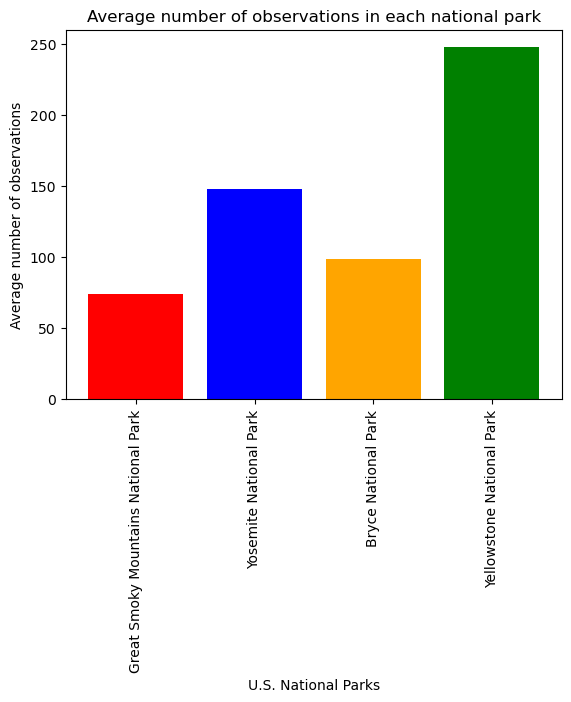

In [23]:
plt.bar(observations.park_name.unique(), observation_means, color=colours)
plt.title("Average number of observations in each national park")
plt.xlabel("U.S. National Parks")
plt.ylabel("Average number of observations")
plt.xticks(rotation='vertical')
plt.show()

Among the four national parks included in the **observations** database, Yellowstone National Park saw the largest average number of observations, while Great Smoky Mountains National Park had the smallest average. In other words, in Yellowstone, more animals were observed on average than at any of the other national parks included in the database. Based on this information, if I were considering a trip to a national park and one of my considerations when deciding which park to visit was what the odds were that I would be able to see a wild animal there, I would pick Yellowstone National Park.

### Analysis of "species" data

#### Distribution of conservation status

In [24]:
species.conservation_status.unique()

array(['Unknown', 'Species of Concern', 'Endangered', 'Threatened',
       'In Recovery'], dtype=object)

In [25]:
species.conservation_status.nunique()

5

There are five category options for the conservation status of every species featured in the **species** dataset: Endangered, Threatened, Species of Concern, In Recovery, and Unknown. I know that of the 5824 values included in the dataset, 191 are assigned a conservation status other than "Unknown" (see **Fill missing values** section above). I am only interested in looking at the known conservation status of the animals featured in the dataset, so I will start by creating a new dataset, **species_filtered**, which excludes values where the *conservation_status* is listed as "Unknown".

In [26]:
species_filtered = species[species.conservation_status != "Unknown"]
species_filtered.head(10)

,category,scientific_name,common_names,conservation_status
7,Mammal,Canis latrans,Coyote,Species of Concern
8,Mammal,Canis lupus,Gray Wolf,Endangered
9,Mammal,Canis rufus,Red Wolf,Endangered
29,Mammal,Eptesicus fuscus,Big Brown Bat,Species of Concern
30,Mammal,Lasionycteris noctivagans,Silver-Haired Bat,Species of Concern
33,Mammal,Myotis austroriparius,"Mississippi Myotis, Southeastern Myotis",Species of Concern
34,Mammal,Myotis grisescens,Gray Myotis,Endangered
35,Mammal,Myotis keenii,Keen's Myotis,Species of Concern
36,Mammal,Myotis leibii,"Eastern Small-Footed Bat, Eastern Small-Footed...",Species of Concern
37,Mammal,Myotis lucifugus,"Little Brown Bat, Little Brown Myotis",Species of Concern


In [27]:
species_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191 entries, 7 to 5676
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             191 non-null    object
 1   scientific_name      191 non-null    object
 2   common_names         191 non-null    object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 7.5+ KB


Now that I have created a new dataset which features every species that is assigned a conservation status label, I will now begin to develop a bar plot showing the distribution of each status label. First, I will create a list of the four labels, assigned to the variable name *conservation_status_ordered*, listing them in order from most to least "in danger". This will later be used to organize the final bar plot so the findings are listed in that order.

In [28]:
conservation_status_ordered = ["Endangered", "Threatened", "Species of Concern", "In Recovery"]

Now using the dataset **species_filtered** and the list *conservation_status_ordered*, I will create a barplot illustrating the distribution of animal species conservation statuses.

C:\Users\koral\AppData\Local\Temp\ipykernel_23296\3907386465.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = species_filtered.conservation_status, order=conservation_status_ordered, palette="Dark2")


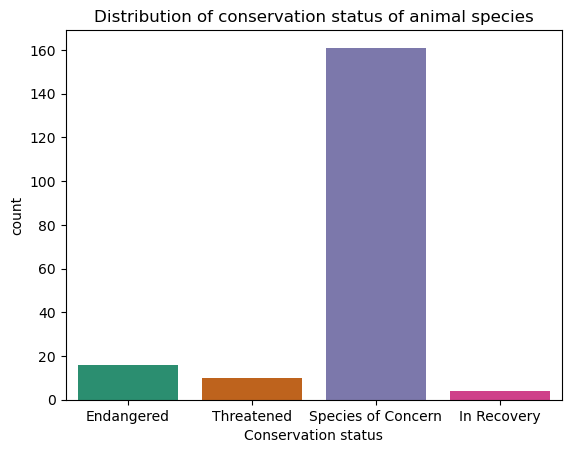

In [29]:
sns.countplot(x = species_filtered.conservation_status, order=conservation_status_ordered, palette="Dark2")
plt.title("Distribution of conservation status of animal species")
plt.xlabel("Conservation status")
plt.show()

Of the animals which were assigned a conservation status label in the **species** dataset, the majority are categoried as "Species of "Concern". For the remaining three status labels, "Endangered", "Threatened", and "In Recovery", each label has been assigned to less than 20 species included in the database. 

#### Distribution of categories

In [30]:
species.category.unique()

array(['Mammal', 'Bird', 'Reptile', 'Amphibian', 'Fish', 'Vascular Plant',
       'Nonvascular Plant'], dtype=object)

In [31]:
species.category.nunique()

7

The animals and plants featured in the **species** dataset are organized into seven categories of taxonomic class: Mammal, Bird, Reptile, Amphibian, Fish, Vascular Plant, and Nonvascular Plant. Using the dataset, I will create a countplot in seaborn which shows the distribution of species belonging to each class.

C:\Users\koral\AppData\Local\Temp\ipykernel_23296\186434059.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = species.category, palette = "Dark2")


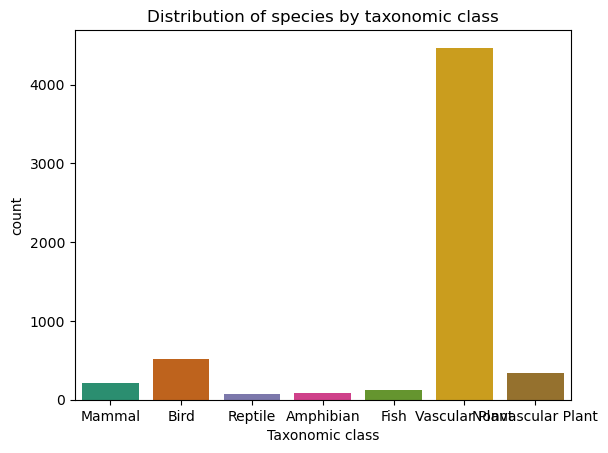

In [32]:
sns.countplot(x = species.category, palette = "Dark2")
plt.title("Distribution of species by taxonomic class")
plt.xlabel("Taxonomic class")
plt.show()

Looking at the above countplot organizing the species by their taxonomic class shows the data is very skewed, with the class "Vascular Plant" making up the vast majority of species in the dataset. Therefore, it would be useful to divide up the data further by separating the species based on the kingdoms they belong to: Animalia and Plantae, assigned to the variables **animalia** and **plantae**.

In [33]:
animalia = species[species.category.isin(["Mammal", "Bird", "Reptile", "Amphibian", "Fish"])]
plantae = species[species.category.isin(["Vascular Plant", "Nonvascular Plant"])]

C:\Users\koral\AppData\Local\Temp\ipykernel_23296\87237594.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = animalia.category, palette="tab10")


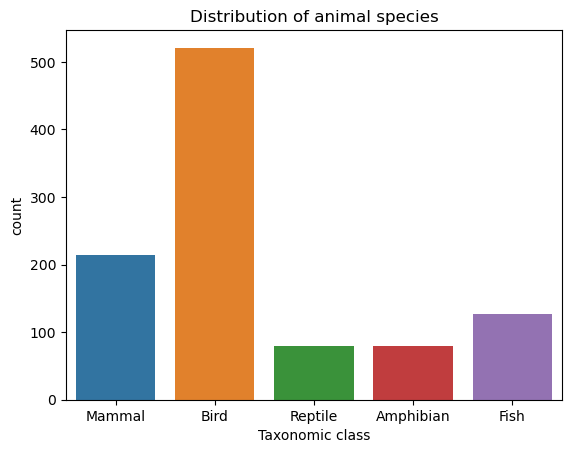

In [34]:
sns.countplot(x = animalia.category, palette="tab10")
plt.title("Distribution of animal species")
plt.xlabel("Taxonomic class")
plt.show()

C:\Users\koral\AppData\Local\Temp\ipykernel_23296\88012893.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = plantae.category, palette="tab10")


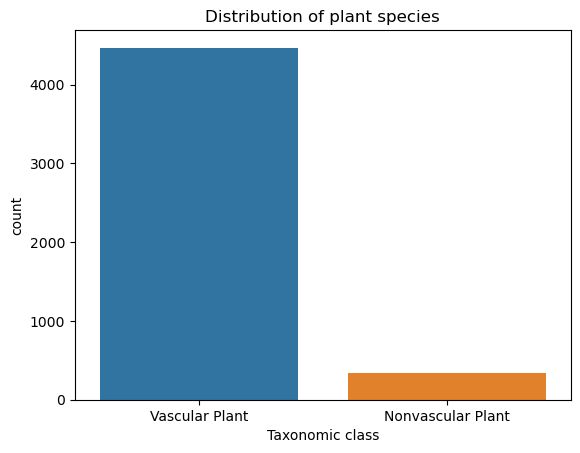

In [35]:
sns.countplot(x = plantae.category, palette="tab10")
plt.title("Distribution of plant species")
plt.xlabel("Taxonomic class")
plt.show()

Now that the species are separated by kingdoms, it is easier to see the distribution of both the plant and animal species included in the **species** dataset. Within the **animalia** dataset, birds are the most common class of animals and within the **plantae** dataset, vascular plants are the most common class of plants.

### Merging and analysis of "observations" and "species"

There are two more questions I wish to address using the data included in the **biodiversity** package:
1. Is there a correlation between an animal's conservation status and the number of observations of that animal?
2. What is the distribution of observations for each animal category (Mammal, Amphibian, etc.)?

In order to successfully address and give an answer to these questions, I need to merge the data from the **observations** and **species** datasets. I will begin with merging these two and assigning them to the variable **biodiversity** and cleaning and prepping that new dataframe to be analysed.

#### Merging "biodiversity"

Let's start by recalling the content of the **observations** and **species** datasets:

In [36]:
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


In [37]:
observations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23281 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23281 non-null  object
 1   park_name        23281 non-null  object
 2   observations     23281 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 727.5+ KB


In [38]:
species.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,Unknown
1,Mammal,Bos bison,"American Bison, Bison",Unknown
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",Unknown
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",Unknown
4,Mammal,Cervus elaphus,Wapiti Or Elk,Unknown


In [39]:
species.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  5824 non-null   object
dtypes: object(4)
memory usage: 182.1+ KB


These two datasets have the column *scientific_name* in common, so a merge of the two datasets together should combine the two together.

In [40]:
biodiversity = pd.merge(observations, species)
biodiversity.head(10)

,scientific_name,park_name,observations,category,common_names,conservation_status
0,Vicia benghalensis,Great Smoky Mountains National Park,68,Vascular Plant,"Purple Vetch, Reddish Tufted Vetch",Unknown
1,Neovison vison,Great Smoky Mountains National Park,77,Mammal,American Mink,Unknown
2,Prunus subcordata,Yosemite National Park,138,Vascular Plant,Klamath Plum,Unknown
3,Abutilon theophrasti,Bryce National Park,84,Vascular Plant,Velvetleaf,Unknown
4,Githopsis specularioides,Great Smoky Mountains National Park,85,Vascular Plant,Common Bluecup,Unknown
5,Elymus virginicus var. virginicus,Yosemite National Park,112,Vascular Plant,Virginia Wildrye,Unknown
6,Spizella pusilla,Yellowstone National Park,228,Bird,Field Sparrow,Unknown
7,Elymus multisetus,Great Smoky Mountains National Park,39,Vascular Plant,"Big Squirreltail, Big Wild Rye",Unknown
8,Lysimachia quadrifolia,Yosemite National Park,168,Vascular Plant,Whorled Loosestrife,Unknown
9,Diphyscium cumberlandianum,Yellowstone National Park,250,Nonvascular Plant,Cumberland Diphyscium Moss,Unknown


In [41]:
biodiversity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25601 entries, 0 to 25600
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   scientific_name      25601 non-null  object
 1   park_name            25601 non-null  object
 2   observations         25601 non-null  int64 
 3   category             25601 non-null  object
 4   common_names         25601 non-null  object
 5   conservation_status  25601 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.2+ MB


#### Correlation between conservation status and number of observations

In [42]:
conservation_status_ordered = ["Endangered", "Threatened", "Species of Concern", "In Recovery", "Unknown"]

In [43]:
sum_of_observations = biodiversity.groupby("conservation_status").sum("observations")
sum_of_observations

,observations
conservation_status,
Endangered,3513
In Recovery,2107
Species of Concern,93962
Threatened,3339
Unknown,3537451


C:\Users\koral\AppData\Local\Temp\ipykernel_23296\1756569044.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=biodiversity, x='conservation_status', y='observations', order=conservation_status_ordered, palette='tab10')


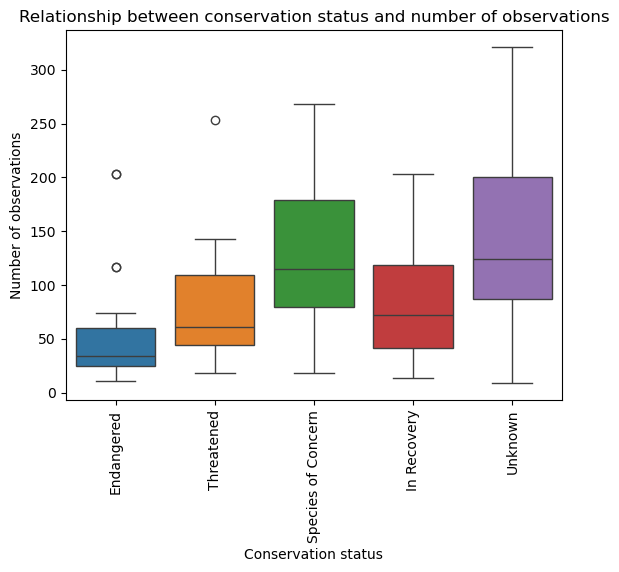

In [44]:
sns.boxplot(data=biodiversity, x='conservation_status', y='observations', order=conservation_status_ordered, palette='tab10')
plt.title("Relationship between conservation status and number of observations")
plt.xlabel("Conservation status")
plt.ylabel("Number of observations")
plt.xticks(rotation='vertical')
plt.show()

Naturally, the category of conservation status which has the largest distribution of observations is "Unknown", due to the large number of species which were not assigned a conservation category. That aside, of the four main categories of conservation status, the group with the most observations is "Species of Concern". I found this surprising as I expected the category representing the best conserved species, "In Recovery", would yield the most observations by nature of those species being in the least danger of extinction.

As I continue through the Career Path and learn about linear regression and noramlization of data, I can investigate how to factor in the total number of species belonging to each conservation category when investigating this distribution, but that is for a later discussion.

#### Distribution of observations by taxonomic class

C:\Users\koral\AppData\Local\Temp\ipykernel_23296\570035908.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=biodiversity, x='category', y='observations', palette='tab10')


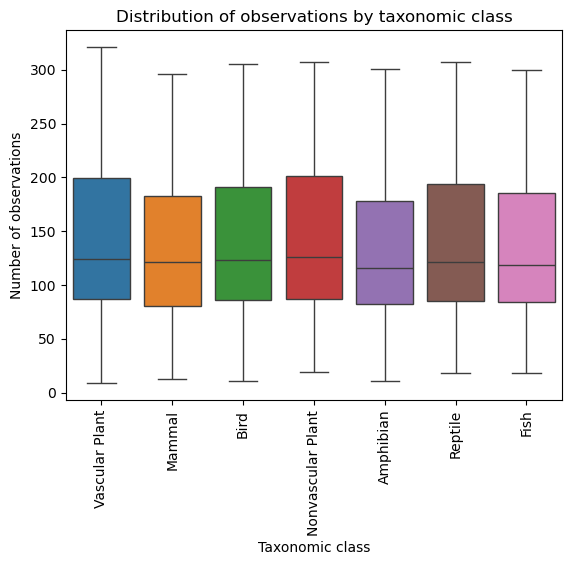

In [45]:
sns.boxplot(data=biodiversity, x='category', y='observations', palette='tab10')
plt.title("Distribution of observations by taxonomic class")
plt.xlabel("Taxonomic class")
plt.ylabel("Number of observations")
plt.xticks(rotation="vertical")
plt.show()

For the most part, there is an even distribution of the different taxonomic classes included in the **biodiversity** dataset. The one outlier is the class of "Vascular Plant", which, as already indicated in the "Distribution of categories" analysis above, is the single largest taxonomic class included in the database. Therefore, it makes sense that "Vascular Plants" make up the group of animals with the largest distribution of observations.